# Velocidad de convergencia: Jacobi, Seidel y Descenso profundo

**Métodos Numéricos · Tarea 3**

Se estima la velocidad de convergencia de los métodos de **Jacobi**, **Seidel** y **descenso profundo** de dos formas: la **tasa teórica** (radio espectral y número de condición) y la **tasa empírica** (a partir de las iteraciones). Después se verifica con las seis matrices de prueba de la Tarea 1.

Contenido:

1. Métodos iterativos
2. Tasa teórica
3. Tasa empírica
4. Experimento
5. Resultados por matriz
6. Aplicabilidad y comparación con la Tarea 1

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matrices import MATRICES, sistema      # matrices de la Tarea 1

%matplotlib inline

GUARDAR = True
TOL = 1e-9           # tolerancia relativa del residuo
KMAX = 100000        # máximo de iteraciones

## 1. Métodos iterativos

Con $A=D+L+U$ ($D$ la diagonal, $L$ y $U$ las partes estrictamente inferior y superior):

- **Jacobi:** $x_i^{(k+1)}=\dfrac{1}{a_{ii}}\Big(b_i-\sum_{j\neq i}a_{ij}x_j^{(k)}\Big)$. Solo usa la iterada anterior.
- **Seidel:** igual, pero usa las componentes $x_j^{(k+1)}$ ($j<i$) que ya se calcularon en esa misma iteración.
- **Descenso profundo** (solo $A$ simétrica definida positiva): $\alpha_k=\dfrac{\mathbf r_k^T\mathbf r_k}{\mathbf r_k^TA\mathbf r_k}$, $\ \mathbf x_{k+1}=\mathbf x_k+\alpha_k\mathbf r_k$.

Los tres paran cuando $\|\mathbf r_k\|\le tol\,\|\mathbf r_0\|$, cuando $k=k_{\max}$, o cuando $\|\mathbf r_k\|\ge10^{10}\|\mathbf r_0\|$ (divergencia). Devuelven la última iterada `x`, el número de iteraciones `k` y la matriz `X` con todas las iteradas (cada fila es una iterada).

In [2]:
def jacobi(A, b, x0, kmax, tol=1e-9):
    # Cada componente usa solo la iterada anterior: x_new = (b - (L+U) x) / d
    d = np.diag(A)
    x = x0.copy()
    r = b - A @ x
    r0 = np.linalg.norm(r)
    X = [x]
    k = 0
    while tol * r0 < np.linalg.norm(r) < 1e10 * r0 and k < kmax:
        x = (b - A @ x + d * x) / d          # A@x - d*x = (L+U) x
        r = b - A @ x
        X.append(x)
        k += 1
    return x, k, np.array(X)


def seidel(A, b, x0, kmax, tol=1e-9):
    # Cada componente usa ya las componentes nuevas de esta misma iteracion.
    n = len(b)
    x = x0.copy()
    r = b - A @ x
    r0 = np.linalg.norm(r)
    X = [x.copy()]
    k = 0
    while tol * r0 < np.linalg.norm(r) < 1e10 * r0 and k < kmax:
        for i in range(n):
            x[i] = (b[i] - A[i, :i] @ x[:i] - A[i, i+1:] @ x[i+1:]) / A[i, i]
        r = b - A @ x
        X.append(x.copy())
        k += 1
    return x, k, np.array(X)


def descenso(A, b, x0, kmax, tol=1e-9):
    # Avanza en la direccion del residuo con el paso que minimiza la energia.
    x = x0.copy()
    r = b - A @ x
    r0 = np.linalg.norm(r)
    X = [x]
    k = 0
    while tol * r0 < np.linalg.norm(r) < 1e10 * r0 and k < kmax:
        alpha = (r @ r) / (r @ (A @ r))
        x = x + alpha * r
        r = b - A @ x
        X.append(x)
        k += 1
    return x, k, np.array(X)

### Validación

Se prueban con un sistema pequeño cuya solución se conoce, $A=\begin{pmatrix}3&2\\2&6\end{pmatrix}$, $\mathbf b=(5,8)^T$ (solución $(1,1)^T$), y se compara con `numpy.linalg.solve`.

In [3]:
A2 = np.array([[3., 2.], [2., 6.]])
b2 = np.array([5., 8.])
ref = np.linalg.solve(A2, b2)

for nombre, f in [("Jacobi", jacobi), ("Seidel", seidel), ("Descenso profundo", descenso)]:
    x, k, X = f(A2, b2, np.zeros(2), KMAX, TOL)
    print(f"{nombre:18s} k = {k:3d}   max|x - solve| = {np.max(np.abs(x - ref)):.2e}")

Jacobi             k =  28   max|x - solve| = 7.16e-10
Seidel             k =  14   max|x - solve| = 2.15e-09
Descenso profundo  k =  10   max|x - solve| = 9.41e-10


## 2. Tasa teórica

Los métodos de Jacobi y Seidel son $\mathbf x_{k+1}=B\,\mathbf x_k+\mathbf c$, así que $\mathbf e_{k+1}=B\,\mathbf e_k$ y la razón de convergencia es el radio espectral $\rho(B)$:

$$B_J=-D^{-1}(L+U),\qquad B_{GS}=-(D+L)^{-1}U,\qquad \rho(B)=\max_i|\lambda_i(B)|.$$

Convergen para todo $\mathbf x_0$ si y solo si $\rho(B)<1$. Para descenso profundo no hay matriz de iteración fija; se usa la cota en la norma de la energía,

$$\frac{\|\mathbf e_{k+1}\|_A}{\|\mathbf e_k\|_A}\le\frac{\kappa-1}{\kappa+1},\qquad \kappa=\mathrm{cond}_2(A).$$

El número de iteraciones estimado para reducir el residuo en un factor `TOL` es $k\approx\ln(\mathrm{TOL})/\ln\rho$.

Si la diagonal tiene un cero, Jacobi y Seidel **no están definidos**; si $A$ no es simétrica definida positiva, descenso profundo **no aplica**. En ambos casos la tasa se devuelve como `nan`.

In [4]:
def es_spd(A):
    return np.allclose(A, A.T) and np.all(np.linalg.eigvalsh(A) > 0)


def tasas_teoricas(A):
    # Devuelve {'J': rho(B_J), 'GS': rho(B_GS), 'DP': (kappa-1)/(kappa+1)}.
    D = np.diag(np.diag(A)); L = np.tril(A, -1); U = np.triu(A, 1)
    t = {"J": np.nan, "GS": np.nan, "DP": np.nan}
    if np.all(np.diag(A) != 0):
        t["J"] = max(abs(np.linalg.eigvals(-np.linalg.solve(D, L + U))))
        t["GS"] = max(abs(np.linalg.eigvals(-np.linalg.solve(D + L, U))))
    if es_spd(A):
        kappa = np.linalg.cond(A)
        t["DP"] = (kappa - 1) / (kappa + 1)
    return t


t = tasas_teoricas(A2)
print("A = [[3,2],[2,6]]")
print(f"rho(B_J)  = {t['J']:.6f}   (esperado sqrt(2/9) = {np.sqrt(2/9):.6f})")
print(f"rho(B_GS) = {t['GS']:.6f}   (esperado 2/9 = {2/9:.6f}, es rho_J^2)")
print(f"cota DP   = {t['DP']:.6f}")

A = [[3,2],[2,6]]
rho(B_J)  = 0.471405   (esperado sqrt(2/9) = 0.471405)
rho(B_GS) = 0.222222   (esperado 2/9 = 0.222222, es rho_J^2)
cota DP   = 0.555556


## 3. Tasa empírica

Se guarda, en cada iteración, el residuo relativo $\|\mathbf r_k\|/\|\mathbf b\|$ y el error relativo $\|\mathbf x_k-\mathbf x\|/\|\mathbf x\|$ (la solución exacta es el vector de unos, como en la Tarea 1). Con ellos se estiman dos tasas:

- **Geométrica:** $\hat\rho_{\text{geom}}=\big(\|\mathbf r_k\|/\|\mathbf r_0\|\big)^{1/k}$. Es el promedio de toda la corrida, incluido el transitorio inicial.
- **Ajuste:** $\hat\rho_{\text{ajuste}}=e^{m}$, con $m$ la pendiente del ajuste lineal de $\ln\|\mathbf e_j\|$ contra $j$ en la **segunda mitad** de las iteraciones, donde ya domina el comportamiento asintótico.

Si en la segunda mitad no hay al menos dos errores positivos (por ejemplo, el error ya es exactamente cero), el ajuste devuelve `nan`.

In [5]:
def tasas_empiricas(res, err):
    k = len(res) - 1
    geom = np.nan if k < 1 else (res[-1] / res[0]) ** (1 / k)
    j = np.arange(k // 2, k + 1)
    j = j[err[j] > 0]
    ajuste = np.nan if len(j) < 2 else np.exp(np.polyfit(j, np.log(err[j]), 1)[0])
    return geom, ajuste

## 4. Experimento

Para cada matriz y cada $n$ se toma $\mathbf b=A\mathbf 1$, $\mathbf x_0=\mathbf 0$ y se corren los tres métodos (`J` = Jacobi, `GS` = Seidel, `DP` = descenso profundo). Se registra el estado:

| estado | significado |
|---|---|
| `converge` | se alcanzó `TOL` |
| `diverge` | el residuo creció $10^{10}$ veces |
| `kmax` | se agotaron las iteraciones sin llegar a `TOL` |
| `no definido` | diagonal con ceros (Jacobi y Seidel) |
| `no aplica` | $A$ no es simétrica definida positiva (descenso profundo) |

Como en las matrices SPD mal condicionadas hacen falta del orden de $\kappa$ iteraciones, los tamaños son pequeños. En `forsythe` la diagonal es cero, así que además se prueba la versión con las filas permutadas, $PA=\mathrm{diag}(\alpha,1,\dots,1)$ (`forsythe perm`), que sí tiene diagonal no nula.

In [6]:
NS = {"cauchy": [3, 4, 5, 6], "chebvand": [3, 4, 5, 6], "forsythe": [10, 30, 50],
      "hilb": [3, 4, 5, 6], "kahan": [10, 20, 30, 40], "moler": [3, 4, 5, 6, 8]}
N_REF = {"cauchy": 5, "chebvand": 5, "forsythe": 30, "hilb": 5, "kahan": 30, "moler": 5}
CASOS = {"forsythe": ["forsythe", "forsythe perm"]}      # los demás: solo su propio nombre
METODOS = {"J": jacobi, "GS": seidel, "DP": descenso}


def construir(caso, n):
    if caso == "forsythe perm":
        A, b = sistema(MATRICES["forsythe"](n))
        return np.roll(A, 1, axis=0), np.roll(b, 1)      # sube cada fila: PA es diagonal
    return sistema(MATRICES[caso](n))


def correr_caso(caso, n):
    A, b = construir(caso, n)
    teo = tasas_teoricas(A)
    filas, hist = [], {}
    for m, f in METODOS.items():
        fila = dict(caso=caso, n=n, m=m, rho_teo=teo[m], rho_geom=np.nan, rho_ajuste=np.nan,
                    k=np.nan, k_pred=np.nan, error=np.nan, pico=np.nan)
        if np.isnan(teo[m]):
            fila["estado"] = "no aplica" if m == "DP" else "no definido"
        else:
            x, k, X = f(A, b, np.zeros(n), KMAX, TOL)
            res = np.linalg.norm(b[:, None] - A @ X.T, axis=0) / np.linalg.norm(b)
            err = np.linalg.norm(X - 1, axis=1) / np.sqrt(n)
            fila["rho_geom"], fila["rho_ajuste"] = tasas_empiricas(res, err)
            fila["k"], fila["error"], fila["pico"] = k, err[-1], err.max() / err[0]
            if 0 < teo[m] < 1:
                fila["k_pred"] = np.log(TOL) / np.log(teo[m])
            fila["estado"] = "converge" if res[-1] <= TOL else ("diverge" if k < KMAX else "kmax")
            hist[(caso, n, m)] = (res, err)
        filas.append(fila)
    return filas, hist


def experimento(nombre):
    filas, hist = [], {}
    for caso in CASOS.get(nombre, [nombre]):
        for n in NS[nombre]:
            f, h = correr_caso(caso, n)
            filas += f
            hist.update(h)
    return filas, hist

Las funciones siguientes dan formato a la tabla y la guardan como `tablas/t3_<matriz>.tex`.

In [7]:
def f_rho(v):
    if np.isnan(v): return "—"
    if v == 0: return "0"
    return f"{v:.8f}" if v < 1 else f"{v:.4g}"

def f_sci(v):
    return "—" if np.isnan(v) else f"{v:.2e}"

def f_int(v):
    return "—" if np.isnan(v) else f"{int(round(v))}"


def formatear(filas, pico=False):
    df = pd.DataFrame(filas)
    sufijo = np.where(df["caso"].str.endswith("perm"), " perm.", "")
    out = pd.DataFrame({"n": df["n"], "método": df["m"] + sufijo,
                        "ρ teórico": df["rho_teo"].map(f_rho),
                        "ρ geom.": df["rho_geom"].map(f_rho),
                        "ρ ajuste": df["rho_ajuste"].map(f_rho),
                        "k": df["k"].map(f_int), "k pred.": df["k_pred"].map(f_int),
                        "estado": df["estado"], "error rel.": df["error"].map(f_sci)})
    if pico:
        out["pico del error"] = df["pico"].map(f_sci)
    return out


ENC = {"ρ teórico": r"$\rho$ teórico", "ρ geom.": r"$\hat\rho_{\mathrm{geom}}$",
       "ρ ajuste": r"$\hat\rho_{\mathrm{ajuste}}$", "cond(A)": r"$\cond(A)$"}

def a_tex(s):
    s = str(s).replace("—", "---")
    return re.sub(r"(\d\.\d+)e([+-]\d+)",
                  lambda m: rf"${m.group(1)}\times10^{{{int(m.group(2))}}}$", s)


def guardar_tabla(df, archivo, texttt=False):
    if not GUARDAR:
        return
    os.makedirs("tablas", exist_ok=True)
    filas = []
    for _, r in df.iterrows():
        celdas = [a_tex(v) for v in r]
        if texttt:
            celdas[0] = r"\texttt{" + celdas[0] + "}"
        filas.append(" & ".join(celdas) + r" \\")
    cab = " & ".join(ENC.get(c, c) for c in df.columns) + r" \\"
    cuerpo = [r"{\scriptsize", r"\begin{tabular}{" + "c" * len(df.columns) + "}", r"\toprule",
              r"\rowcolor{Azul1!50}", cab, r"\midrule", *filas, r"\bottomrule", r"\end{tabular}}"]
    with open(f"tablas/{archivo}.tex", "w", encoding="utf-8") as fh:
        fh.write("\n".join(cuerpo) + "\n")

La figura de cada matriz tiene dos paneles: a la izquierda, el residuo relativo contra $k$ (escala logarítmica) para el tamaño de referencia; a la derecha, $\rho$ contra $n$ (línea: teórico, $\times$: ajuste empírico), con la recta $\rho=1$ como frontera de la convergencia. En `kahan`, donde $\rho=0$, el panel derecho muestra en cambio $\|B^k\|_2$.

In [8]:
COLOR = {"J": "C0", "GS": "C1", "DP": "C2"}

def potencias_kahan(n):
    A = MATRICES["kahan"](n)
    B = -np.triu(A, 1) / np.diag(A)[:, None]            # B_J = B_GS = -D^{-1} U
    M, normas = np.eye(n), [1.0]
    for _ in range(n):
        M = M @ B
        normas.append(np.linalg.norm(M, 2))
    return np.array(normas)


def figura(nombre, filas, hist, derecha="rho"):
    n_ref = N_REF[nombre]
    fig, axs = plt.subplots(1, 1 if derecha is None else 2, figsize=(11 if derecha else 5.5, 3.8), squeeze=False)
    ax = axs[0, 0]
    for (caso, n, m), (res, err) in hist.items():
        if n == n_ref:
            ax.loglog(np.arange(1, len(res)), np.maximum(res[1:], 1e-18), color=COLOR[m],
                      ls="--" if caso.endswith("perm") else "-", marker="o" if len(res) < 50 else None,
                      ms=3, label=m + (" perm." if caso.endswith("perm") else ""))
    ax.axhline(TOL, color="gray", ls=":")
    ax.set(title=f"{nombre}, n = {n_ref}", xlabel="k", ylabel=r"$\|r_k\|/\|b\|$")
    ax.grid(alpha=.3); ax.legend()
    if derecha == "rho":
        ax = axs[0, 1]
        df = pd.DataFrame(filas)
        for (caso, m), g in df.groupby(["caso", "m"]):
            g = g[g["rho_teo"] > 0]
            if len(g):
                ax.semilogy(g["n"], g["rho_teo"], marker="o", ms=3, color=COLOR[m],
                            ls="--" if caso.endswith("perm") else "-", label=m + (" perm." if caso.endswith("perm") else ""))
                ax.semilogy(g["n"], g["rho_ajuste"], "x", color="k", ms=5)
        ax.axhline(1, color="gray", ls=":")
        ax.set(title=r"$\rho$ contra $n$", xlabel="n", ylabel=r"$\rho$", xticks=NS[nombre])
        ax.grid(alpha=.3); ax.legend()
    elif derecha == "potencias":
        ax = axs[0, 1]
        for n in NS[nombre]:
            ax.semilogy(np.maximum(potencias_kahan(n), 1e-18), label=f"n = {n}")
        ax.set(title=r"$\|B^k\|_2$ (transitorio)", xlabel="k", ylabel=r"$\|B^k\|_2$")
        ax.grid(alpha=.3); ax.legend()
    fig.tight_layout()
    if GUARDAR:
        os.makedirs("figuras", exist_ok=True)
        fig.savefig(f"figuras/t3_{nombre}.pdf")
    plt.show()


RESULTADOS = {}

def mostrar(nombre, derecha="rho", pico=False):
    filas, hist = experimento(nombre)
    RESULTADOS[nombre] = filas
    vista = formatear(filas, pico)
    display(vista.set_index("n"))
    guardar_tabla(vista, f"t3_{nombre}")
    figura(nombre, filas, hist, derecha)

## 5. Resultados por matriz

### Cauchy

SPD y mal condicionada. Seidel y descenso profundo convergen en teoría; Jacobi depende de $\rho(B_J)$.

,método,ρ teórico,ρ geom.,ρ ajuste,k,k pred.,estado,error rel.
n,,,,,,,,
3,J,1.86,1.86,1.86,38,—,diverge,1.87e+10
3,GS,0.99431440,0.99040183,0.99431440,2149,3634,converge,9.28e-07
3,DP,0.99852321,0.99636798,0.99820590,5696,14022,converge,1.11e-06
4,J,2.763,2.762,2.763,23,—,diverge,1.56e+10
4,GS,0.99975321,0.99929371,0.99975321,29331,83960,converge,3.48e-05
4,DP,0.99995641,0.99980002,0.99995576,100000,475397,kmax,6.80e-05
5,J,3.659,3.656,3.659,18,—,diverge,1.54e+10
5,GS,0.99999010,0.99980407,0.99999010,100000,2094288,kmax,3.77e-03
5,DP,0.99999870,0.99961870,0.99999818,54339,15905561,converge,9.44e-04


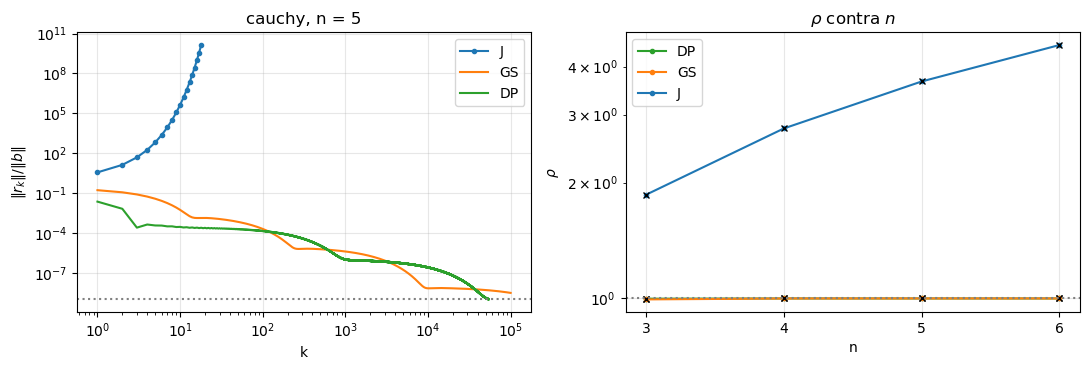

In [9]:
mostrar("cauchy", derecha='rho', pico=False)

### Chebyshev–Vandermonde

No es simétrica, así que descenso profundo no aplica. Jacobi y Seidel dependen de $\rho$.

,método,ρ teórico,ρ geom.,ρ ajuste,k,k pred.,estado,error rel.
n,,,,,,,,
3,J,1.611,1.602,1.609,49,—,diverge,1.24e+10
3,GS,2.732,2.716,2.732,24,—,diverge,2.59e+10
3,DP,—,—,—,—,—,no aplica,—
4,J,5.379,5.357,5.439,14,—,diverge,2.10e+10
4,GS,51.29,48.16,51.29,6,—,diverge,1.59e+10
4,DP,—,—,—,—,—,no aplica,—
5,J,3.715,3.705,3.697,18,—,diverge,1.71e+10
5,GS,8.932,8.786,8.932,11,—,diverge,6.62e+10
5,DP,—,—,—,—,—,no aplica,—


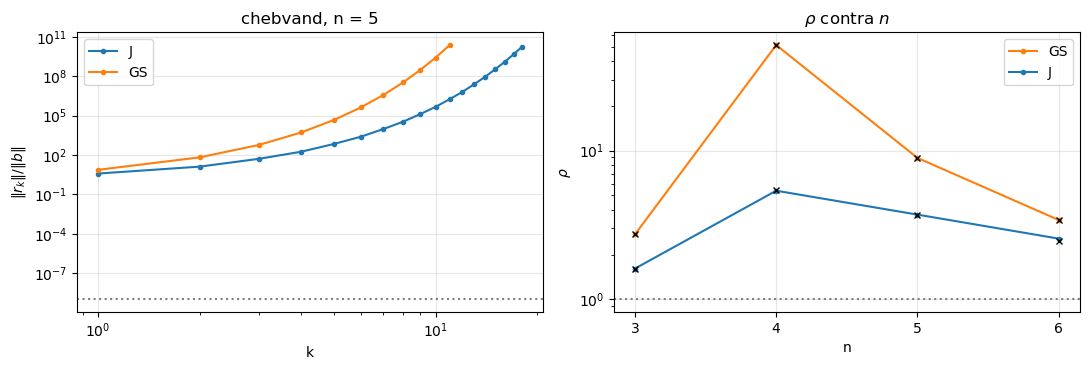

In [10]:
mostrar("chebvand", derecha='rho', pico=False)

### Forsythe

Con $\lambda=0$ la diagonal es cero: Jacobi y Seidel no están definidos. Con las filas permutadas, $PA=\mathrm{diag}(\alpha,1,\dots,1)$ es diagonal y simétrica definida positiva, así que los tres métodos están definidos. La figura tiene un solo panel porque $\rho=0$ en Jacobi y Seidel.

,método,ρ teórico,ρ geom.,ρ ajuste,k,k pred.,estado,error rel.
n,,,,,,,,
10,J,—,—,—,—,—,no definido,—
10,GS,—,—,—,—,—,no definido,—
10,DP,—,—,—,—,—,no aplica,—
30,J,—,—,—,—,—,no definido,—
30,GS,—,—,—,—,—,no definido,—
30,DP,—,—,—,—,—,no aplica,—
50,J,—,—,—,—,—,no definido,—
50,GS,—,—,—,—,—,no definido,—
50,DP,—,—,—,—,—,no aplica,—


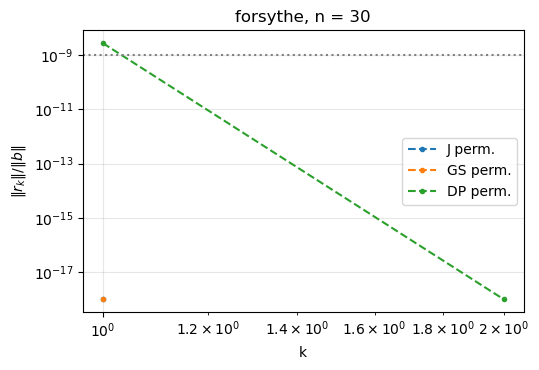

In [11]:
mostrar("forsythe", derecha=None, pico=False)

### Hilbert

SPD y mal condicionada, como Cauchy.

,método,ρ teórico,ρ geom.,ρ ajuste,k,k pred.,estado,error rel.
n,,,,,,,,
3,J,1.723,1.722,1.723,43,—,diverge,1.69e+10
3,GS,0.98085893,0.97149633,0.98085893,717,1072,converge,3.04e-07
3,DP,0.99619089,0.99308985,0.99601712,2989,5430,converge,3.78e-07
4,J,2.582,2.578,2.582,25,—,diverge,2.38e+10
4,GS,0.99902979,0.99775310,0.99902979,9213,21349,converge,1.06e-05
4,DP,0.99987109,0.99961300,0.99986959,53539,160748,converge,1.05e-05
5,J,3.444,3.435,3.444,19,—,diverge,1.94e+10
5,GS,0.99995767,0.99978161,0.99995767,94881,489568,converge,3.48e-04
5,DP,0.99999580,0.99980864,0.99999573,100000,4938429,kmax,1.37e-03


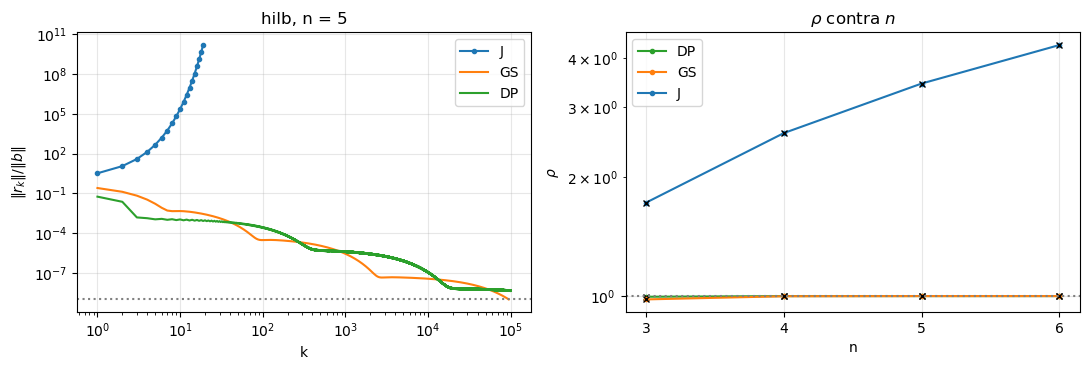

In [12]:
mostrar("hilb", derecha='rho', pico=False)

### Kahan

Triangular superior: $L=0$, así que $B_J=B_{GS}=-D^{-1}U$ es nilpotente y $\rho=0$. En teoría el método termina en a lo sumo $n$ iteraciones, pero $B$ es muy no normal. La columna `pico del error` es $\max_k\|\mathbf e_k\|/\|\mathbf e_0\|$ y mide el crecimiento transitorio que $\rho$ no ve. Descenso profundo no aplica (no es simétrica).

,método,ρ teórico,ρ geom.,ρ ajuste,k,k pred.,estado,error rel.,pico del error
n,,,,,,,,,
10,J,0,0.02431094,0.00319787,10,—,converge,1.40e-16,2.23e+00
10,GS,0,0.02570495,0.00333664,10,—,converge,1.89e-16,2.23e+00
10,DP,—,—,—,—,—,no aplica,—,—
20,J,0,0.31856614,0.12070421,19,—,converge,9.40e-10,2.35e+01
20,GS,0,0.31856613,0.12070420,19,—,converge,9.40e-10,2.35e+01
20,DP,—,—,—,—,—,no aplica,—,—
30,J,0,0.44142329,0.17156333,26,—,converge,2.31e-09,3.52e+02
30,GS,0,0.44142329,0.17156340,26,—,converge,2.31e-09,3.52e+02
30,DP,—,—,—,—,—,no aplica,—,—


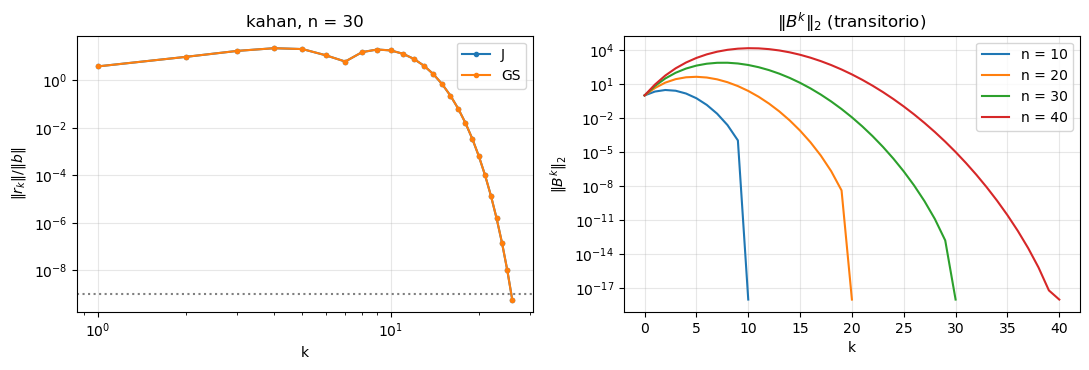

In [13]:
mostrar("kahan", derecha='potencias', pico=True)

### Moler

SPD, pero no diagonalmente dominante, por lo que Jacobi puede no converger aunque Seidel sí.

,método,ρ teórico,ρ geom.,ρ ajuste,k,k pred.,estado,error rel.
n,,,,,,,,
3,J,0.91287093,0.91207268,0.91287093,227,227,converge,1.36e-09
3,GS,0.83333333,0.81893851,0.83333333,104,114,converge,9.41e-09
3,DP,0.93395864,0.91418745,0.92412928,231,303,converge,9.72e-09
4,J,1.132,1.131,1.132,187,—,diverge,7.17e+09
4,GS,0.95203574,0.94222230,0.95203574,349,422,converge,6.23e-08
4,DP,0.98705733,0.97705031,0.98191629,894,1591,converge,6.97e-08
5,J,1.404,1.401,1.404,69,—,diverge,1.13e+10
5,GS,0.98726920,0.98281560,0.98726920,1196,1617,converge,4.07e-07
5,DP,0.99769314,0.99616590,0.99734303,5395,8973,converge,4.49e-07


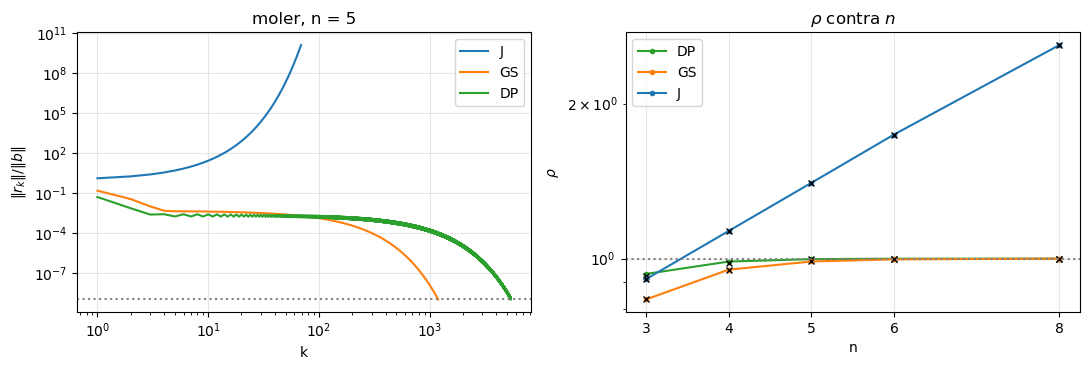

In [14]:
mostrar("moler", derecha='rho', pico=False)

## 6. Aplicabilidad y comparación con la Tarea 1

**Aplicabilidad.** Para el tamaño de referencia de cada matriz (`N_REF`) se junta, por método, el $\rho$ teórico y lo que se observó.

In [15]:
def celda(f):
    if f["estado"] in ("no definido", "no aplica"):
        return f["estado"]
    return f"{f_rho(f['rho_teo'])} ({f['estado']})"

filas = []
for nombre, fs in RESULTADOS.items():
    for caso in CASOS.get(nombre, [nombre]):
        sel = {f["m"]: f for f in fs if f["caso"] == caso and f["n"] == N_REF[nombre]}
        filas.append({"matriz": caso, "n": N_REF[nombre], "Jacobi": celda(sel["J"]),
                      "Seidel": celda(sel["GS"]), "Descenso profundo": celda(sel["DP"])})
aplic = pd.DataFrame(filas)
display(aplic.set_index("matriz"))
guardar_tabla(aplic, "t3_aplicabilidad", texttt=True)

,n,Jacobi,Seidel,Descenso profundo
matriz,,,,
cauchy,5,3.659 (diverge),0.99999010 (kmax),0.99999870 (converge)
chebvand,5,3.715 (diverge),8.932 (diverge),no aplica
forsythe,30,no definido,no definido,no aplica
forsythe perm,30,0 (converge),0 (converge),0.99999997 (converge)
hilb,5,3.444 (diverge),0.99995767 (converge),0.99999580 (kmax)
kahan,30,0 (converge),0 (converge),no aplica
moler,5,1.404 (diverge),0.98726920 (converge),0.99769314 (converge)


**Comparación con la solución directa.** Para el mismo tamaño se compara el error relativo de cada método iterativo con el del método directo. El directo es `numpy.linalg.solve` (LU con pivoteo parcial), equivalente a lo usado en la Tarea 1. Para `forsythe` los iterativos se corren con las filas permutadas. Una celda con `(kmax)` indica que no se llegó a `TOL`.

In [16]:
def celda_error(f):
    if f["estado"] == "converge":
        return f_sci(f["error"])
    return f"{f_sci(f['error'])} (kmax)" if f["estado"] == "kmax" else f["estado"]

filas = []
for nombre, fs in RESULTADOS.items():
    caso = "forsythe perm" if nombre == "forsythe" else nombre
    n = N_REF[nombre]
    A, b = sistema(MATRICES[nombre](n))
    directo = np.linalg.norm(np.linalg.solve(A, b) - 1) / np.sqrt(n)
    sel = {f["m"]: f for f in fs if f["caso"] == caso and f["n"] == n}
    filas.append({"matriz": caso, "n": n, "cond(A)": f_sci(np.linalg.cond(A)),
                  "directo": f_sci(directo), "Jacobi": celda_error(sel["J"]),
                  "Seidel": celda_error(sel["GS"]), "Descenso profundo": celda_error(sel["DP"])})
resumen = pd.DataFrame(filas)
display(resumen.set_index("matriz"))
guardar_tabla(resumen, "t3_resumen", texttt=True)

,n,cond(A),directo,Jacobi,Seidel,Descenso profundo
matriz,,,,,,
cauchy,5,1.54e+06,1.73e-11,diverge,3.77e-03 (kmax),9.44e-04
chebvand,5,5.68e+02,0.00e+00,diverge,diverge,no aplica
forsythe perm,30,6.71e+07,0.00e+00,0.00e+00,0.00e+00,0.00e+00
hilb,5,4.77e+05,3.78e-12,diverge,3.48e-04,1.37e-03 (kmax)
kahan,30,1.40e+05,1.48e-14,2.31e-09,2.31e-09,no aplica
moler,5,8.66e+02,0.00e+00,diverge,4.07e-07,4.49e-07


## Observaciones

- **Teoría y práctica coinciden.** Para Jacobi y Seidel, cuando hay suficientes iteraciones, $\hat\rho_{\text{ajuste}}$ reproduce casi todas las cifras del $\rho(B)$ calculado (por ejemplo, Seidel en Hilbert con $n=3$: $0.98085893$ en ambos), incluso cuando $\rho>1$ y el método diverge. Con pocas iteraciones se desvía un poco (Jacobi en Chebyshev–Vandermonde con $n=6$: $2.455$ frente a $2.562$). En descenso profundo, $\hat\rho_{\text{ajuste}}$ queda por debajo de la cota $(\kappa-1)/(\kappa+1)$, como debe ser.
- **$\hat\rho_{\text{geom}}$ no sirve cuando $\rho\approx1$.** Incluye el transitorio inicial, donde los modos rápidos caen y los lentos casi no se mueven, y por eso queda lejos de $\rho$ (en Cauchy con $n=5$, Seidel: $0.99980$ frente a $0.99999$). El ajuste sobre la segunda mitad sí captura la tasa asintótica.
- **Jacobi diverge en casi todo.** Con $\rho_J>1$ en Cauchy, Hilbert y Chebyshev–Vandermonde para todos los $n$ probados, y en Moler para $n\ge4$ (con $n=3$ sí converge, $\rho_J=0.9129$, y las 227 iteraciones coinciden con la predicha). Seidel tiene $\rho_{GS}<1$ en las tres matrices SPD, mientras que en Chebyshev–Vandermonde ($\rho_{GS}$ entre $2.7$ y $51$) no converge ningún método.
- **$\rho\to1$ al crecer $n$, y las iteraciones se disparan.** En Hilbert, Seidel pasa de 717 a 9 213 y a 94 881 iteraciones para $n=3,4,5$. Varios casos ya no llegan a `TOL` en `KMAX` (estado `kmax`): Seidel en Cauchy con $n\ge5$, descenso profundo en Cauchy con $n=4$ y $6$, en Hilbert con $n\ge5$ y en Moler con $n=8$. El número de iteraciones no es monótono en $n$ (Seidel en Hilbert usa menos con $n=6$ que con $n=5$). Descenso profundo necesita más iteraciones que Seidel en Hilbert y Moler; en Cauchy con $n=5$ ocurre al revés (descenso profundo converge y Seidel no llega).
- **`k pred.` sobreestima.** Es mayor o igual que `k` en todos los casos SPD (solo coincide en Jacobi sobre Moler con $n=3$) porque el criterio de paro usa el residuo, y los modos lentos (los que fijan $\rho$) casi no pesan en el residuo.
- **Residuo pequeño no es error pequeño.** Con residuo relativo $\le10^{-9}$ el error llega a $\approx\kappa\cdot10^{-9}$: en Hilbert con $n=5$ es $3.5\times10^{-4}$ frente a $1.3\times10^{-12}$ del método directo, y en Moler con $n=5$ es $4.1\times10^{-7}$ frente a $0$.
- **Kahan: $\rho=0$ no cuenta toda la historia.** Converge en a lo sumo $n$ iteraciones, pero el error primero crece (pico de $2.2$, $23.5$, $352$ y $5\,790$ veces el error inicial para $n=10,20,30,40$). $\hat\rho_{\text{geom}}$ y $\hat\rho_{\text{ajuste}}$ salen distintos de cero y crecen con $n$; como la convergencia es en tiempo finito, no hay régimen asintótico que medir.
- **Forsythe.** Jacobi y Seidel no están definidos con $\lambda=0$. Con las filas permutadas convergen en 1 iteración con error cero, y descenso profundo en 2, aunque su cota vale casi 1 ($\kappa=6.7\times10^{7}$): la cota es pesimista porque $PA$ solo tiene dos valores propios distintos.
